<a href="https://colab.research.google.com/github/EA88837/Siamese-Networks-for-Image-Similarity-Task/blob/main/pgm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Documentation Blueprint (List Format)

## Section 1: Executive Project Abstract & Problem Statement

### 1.1 Abstract:

This project introduces a novel approach to proactive cybersecurity threat detection and mitigation using **Dynamic Influence Diagrams** and **Probabilistic Graphical Modeling (PGM)**. Addressing the limitations of static Security Information and Event Management (SIEM) systems and prevalent alert fatigue, this model provides a dynamic framework to identify Advanced Persistent Threats (APTs) across multiple time stages. By quantifying the financial impact of various cyber events and defender actions, the system prescribes cost-minimized mitigation strategies, enhancing organizational resilience against evolving cyber threats. It aims to bridge the gap between raw security data and actionable, economically optimized decisions.

### 1.2 Problem Statement:

Enterprises face a critical cybersecurity **double-bind**: the **Inaction Risk** (suffering catastrophic losses from unmitigated breaches) versus the **Overreaction Cost** (incurring significant operational and financial penalties from unnecessary or overly aggressive incident responses). Traditional security systems often generate high volumes of false positives, leading to alert fatigue and a delayed or incorrect response to genuine threats. This project addresses the need for an **automated AI risk orchestrator** that can accurately assess the evolving threat landscape, quantify the potential impact of cyber events, and recommend optimal, cost-effective defense strategies to navigate this complex dilemma.

## Section 2: Structural Network Topology

### 2.1 Chance Nodes (Random Variables):

Our Dynamic Influence Diagram incorporates the following chance nodes, representing random variables with discrete categorical states:

*   **`Phishing_t1`**: Represents the initial compromise attempt at time `t1`.
    *   States: `0` (No Phishing), `1` (Phishing Successful)
*   **`Alert_t1`**: Represents the security alert generated at time `t1`.
    *   States: `0` (No Alert), `1` (Alert Generated)
*   **`Escalation_t2`**: Represents the state of privilege escalation at time `t2`.
    *   States: `0` (Safe), `1` (Breached/Escalated)
*   **`Alert_t2`**: Represents the security alert generated at time `t2`.
    *   States: `0` (No Alert), `1` (Alert Generated)

The relationships between these nodes are defined by directed edges, forming a multi-stage Bayesian Network.

### 2.2 Decision Node (Action Space):

The `Decision_Node` represents the set of possible actions a defender can take in response to observed evidence. The available actions are:

*   `0`: **Ignore Attack**
*   `1`: **Reset Passwords**
*   `2`: **Isolate Server**

The optimal action is chosen by maximizing the Expected Utility, as described in Section 5.

### 2.3 Utility Node (Value Function):

The `Utility_Node` serves as the financial and operational evaluation sink, quantifying the cost (or utility) of different system states under various defender actions. The values are expressed in thousands of dollars ($k). This node directly integrates the financial impact into the decision-making process, allowing the model to select actions that minimize financial losses.

## Section 3: Parameter Design & The Laws of Probability

### 3.1 Modeling Sensor Imperfection (Noisy Channels):

Real-world security sensors are imperfect, generating both False Positives and False Negatives. Our model accounts for these `noisy channels` by defining Conditional Probability Tables (CPTs) that incorporate these quantitative metrics. For instance, the `cpd_alert_t1` and `cpd_alert_t2` capture the probabilities of generating an alert given the true state of `Phishing_t1` or `Escalation_t2` respectively. This allows the model to reason about the reliability of sensor data.

For example, `cpd_alert_t1` contains:
- P(No Alert | No Phishing) = 0.95 (True Negative rate)
- P(Alert | No Phishing) = 0.05 (False Positive rate)
- P(No Alert | Phishing) = 0.15 (False Negative rate)
- P(Alert | Phishing) = 0.85 (True Positive rate)

### 3.2 Joint Probability Factorization:

The structural Direct Acyclic Graph (DAG) of our Bayesian Network implies specific factorization constraints, allowing the joint probability distribution over all variables to be decomposed into a product of local conditional probability distributions. For our `dynamic_cyber_model` with variables `Phishing_t1` ($P_{t1}$), `Alert_t1` ($A_{t1}$), `Escalation_t2` ($E_{t2}$), and `Alert_t2` ($A_{t2}$), the joint distribution can be mathematically proven to factorize as follows:

$$P(P_{t1}, A_{t1}, E_{t2}, A_{t2}) = P(P_{t1}) \cdot P(A_{t1} \mid P_{t1}) \cdot P(E_{t2} \mid P_{t1}) \cdot P(A_{t2} \mid E_{t2})$$

This factorization is fundamental for efficient inference and computation within the network.

## Section 4: Advanced PGM Theoretical Proofs

### 4.1 D-Separation (Directional Separation):

D-Separation is a critical concept for understanding conditional independence in Bayesian Networks. It describes when information flow between two variables is blocked by observing a third. Consider the causal chain `Phishing_t1 ➔ Escalation_t2 ➔ Alert_t2`:

*   **Active Path (Unobserved State)**: Without observing `Escalation_t2`, `Phishing_t1` and `Alert_t2` are dependent. Information about `Phishing_t1` directly influences `Alert_t2`.
*   **Blocked Path (Conditioning on `Escalation_t2`)**: If we observe the state of `Escalation_t2`, it acts as a 'collider' or 'mediator', effectively blocking the information flow between `Phishing_t1` and `Alert_t2`. This makes `Phishing_t1` and `Alert_t2` **d-separated** (conditionally independent) given `Escalation_t2`.

To demonstrate this computationally, we verify if `P(Phishing_t1 | Alert_t2, Escalation_t2)` is approximately equal to `P(Phishing_t1 | Escalation_t2)`. The output from the computational proof is:

```
P(Phishing_t1=1 | Escalation_t2=0) = 0.0200
P(Phishing_t1=1 | Alert_t2=0, Escalation_t2=0) = 0.0200
P(Phishing_t1=1 | Alert_t2=1, Escalation_t2=0) = 0.0200
Are they approximately equal (given Escalation_t2=0)? True

P(Phishing_t1=1 | Escalation_t2=1) = 0.7500
P(Phishing_t1=1 | Alert_t2=0, Escalation_t2=1) = 0.7500
P(Phishing_t1=1 | Alert_t2=1, Escalation_t2=1) = 0.7500
Are they approximately equal (given Escalation_t2=1)? True
```

This computational check confirms that observing `Escalation_t2` indeed d-separates `Phishing_t1` and `Alert_t2`, blocking the flow of information between them through that path, as the probabilities become approximately equal once `Escalation_t2` is known.

### 4.2 Markov Blanket Isolation:

The **Markov Blanket** of a node is the set of its parents, its children, and its children's other parents. Observing the Markov Blanket renders the node conditionally independent of all other nodes in the network, simplifying inference and minimizing computational overhead.

For `Escalation_t2` in our `dynamic_cyber_model`:
*   **Parents**: `Phishing_t1`
*   **Children**: `Alert_t2`
*   **Children's other parents**: (None directly for `Alert_t2`)

The programmatically extracted Markov Blanket for `Escalation_t2` is: `['Alert_t2', 'Phishing_t1']`.

This confirms that to determine the probability of `Escalation_t2`, only the states of `Phishing_t1` and `Alert_t2` are necessary.

### 4.3 Information Theory (Shannon Entropy Collapse):

**Shannon Entropy ($H(X)$)** quantifies the uncertainty or 'surprise' associated with a random variable. A higher entropy value indicates greater uncertainty. By tracking entropy across different phases, we can demonstrate how new information reduces uncertainty in critical variables like `Escalation_t2`.

The formula for Shannon Entropy is:

$$H(X) = -\sum p(x) \log_2 p(x)$$

Tracking the entropy for `Escalation_t2` shows a clear **Entropy Collapse** as more evidence becomes available:

*   **Baseline (Prior to any alerts)**: $H(Escalation_{t2})$ = `0.648` bits
*   **Confusion Spike (After `Alert_t1`)**: $H(Escalation_{t2})$ = `0.964` bits (Note: an alert might initially *increase* uncertainty if it's highly ambiguous or rare, or if it implies new possibilities).
*   **Entropy Collapse (After `Alert_t1` AND `Alert_t2`)**: $H(Escalation_{t2})$ = `0.339` bits

This demonstrates how cumulative evidence significantly reduces the uncertainty about the system's state, improving the confidence of the threat assessment.

## Section 5: Decision Theory & The Financial Utility Model

### 5.1 The Maximum Expected Utility (MEU) Equation:

Our decision-making framework is founded on the **Maximum Expected Utility (MEU) Principle**. The system automatically selects the action `d` that maximizes the expected utility `EU(d|e)` given the observed evidence `e`. The mathematical documentation of this automated optimization logic loop is:

$$\text{Optimal Action} = \arg\max_{d} \sum_{s} P(s \mid e) \times U(s, d)$$

Where:
*   `s` represents the possible states of the world (e.g., `Escalation_t2` being 'Safe' or 'Breached').
*   `P(s|e)` is the probability of a state `s` given the evidence `e`.
*   `U(s, d)` is the utility (or cost) of taking decision `d` when the state of the world is `s`, as defined in the `utility_matrix`.

### 5.2 Risk Aversion & Non-Linear Penalties:

The `utility_matrix` defines the financial impact (in $k) for each combination of system state and defender action. This matrix explicitly incorporates **Risk Aversion** through the assignment of non-linear and asymmetric penalties.

```python
utility_matrix = {
    (0, 0): 0,      # Safe, Ignore -> No cost
    (0, 1): -10,    # Safe, Reset Passwords -> Minor user disruption cost ($10k)
    (0, 2): -100,   # Safe, Isolate Server -> Massive business downtime cost ($100k)
    (1, 0): -500,   # Escalated, Ignore -> Catastrophic Data Breach ($500k loss)
    (1, 1): -300,   # Escalated, Reset Passwords -> Breach partially mitigated ($300k loss)
    (1, 2): -20,    # Escalated, Isolate Server -> Breach stopped instantly (-20k damage)
}
```

**Structural Justification for Asymmetric Penalties:**
*   The cost of ignoring an actual breach (`(1, 0): -500`) is significantly higher than the cost of an unnecessary server isolation (`(0, 2): -100`). This reflects a corporate stance that the financial and reputational damage of a data breach far outweighs the operational disruption of a false positive, even a severe one. The system prioritizes avoiding catastrophic breaches. The cost of `Isolate Server` even when escalated is `-20k`, indicating that isolating a server is a highly effective, albeit disruptive, measure to prevent further damage once a breach is confirmed, significantly reducing the loss compared to other actions in a breached state. This non-linear penalty structure guides the AI towards more conservative, breach-averse decisions when the probability of escalation rises.

## Section 6: Experimental Scenario Analysis & Outputs

### Scenario A (Prior Baseline):

*   **Input Parameters**: No evidence/alerts (empty evidence set).
*   **Calculated Breach Probability**: `16.6%`
*   **Optimal Action**: **Ignore Attack** (Expected Utility: `$-83.0k`)

In a low-threat baseline scenario, the system recommends no action, avoiding unnecessary operational costs.

### Scenario B (Fragmented Evidence):

*   **Input Parameters**: `Alert_t1 = 1` (Phishing Alert at time t1).
*   **Calculated Breach Probability**: `61.1%`
*   **Optimal Action**: **Reset Passwords** (Expected Utility: `$-187.2k`)

With initial evidence of a phishing attempt, the breach probability significantly increases. The system shifts to a more proactive, yet still moderate, response to mitigate potential escalation.

### Scenario C (Critical Escalation):

*   **Input Parameters**: `Alert_t1 = 1`, `Alert_t2 = 1` (Phishing Alert at t1 AND another alert at t2).
*   **Calculated Breach Probability**: `93.7%`
*   **Optimal Action**: **Isolate Server** (Expected Utility: `$-25.0k`)

When faced with strong, compounding evidence suggesting an active breach and escalation, the system recommends the most aggressive response to contain the threat and minimize catastrophic losses, despite the high immediate operational cost. The high breach probability makes the `Isolate Server` action the least costly in terms of expected financial impact.

## Section 7: Conclusion

This project successfully developed a **Dynamic Cyber Threat Detection and Decision Network** using Probabilistic Graphical Modeling. The system effectively:

*   **Integrates multi-stage threat intelligence** across time steps.
*   **Quantifies uncertainty** using entropy metrics.
*   **Applies foundational PGM theory** (D-Separation, Markov Blanket) for robust and efficient inference.
*   **Employs the Maximum Expected Utility principle** for optimal, cost-minimized decision-making under uncertainty.
*   **Demonstrates explainable AI (XAI)** by clearly tracing the logic from evidence to probability calculations and final action recommendations.

This framework provides a powerful tool for bridging data science capabilities with automated incident response, enabling organizations to make informed, economically rational decisions in the face of complex and evolving cyber threats. The dynamic nature of the model allows for continuous adaptation and improvement as new data and threat intelligence become available, offering a significant advantage over static defense strategies.

## Resources

In [43]:
!pip install pgmpy
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination



In [44]:
# ==========================================
# 1. DEFINE MULTI-STAGE GRAPH STRUCTURE
# ==========================================
# Building a network that flows across time steps (t1 -> t2) and feeds into a decision
dynamic_cyber_model = DiscreteBayesianNetwork([
    # Time Step 1 (Infiltration)
    ('Phishing_t1', 'Alert_t1'),
    ('Phishing_t1', 'Escalation_t2'),  # Temporal link mapping t1 to t2

    # Time Step 2 (Exploitation)
    ('Escalation_t2', 'Alert_t2'),
])

print("--- Dynamic PGM Structure Initialized ---")

--- Dynamic PGM Structure Initialized ---


## PGM Foundational Theory: D-Separation

**D-separation** (Directional Separation) is crucial for understanding conditional independence within your network's structure. It tells us when information flow between two variables is blocked by observing a third.

In your `dynamic_cyber_model`, consider the causal chain:

```
Phishing_t1 ➔ Escalation_t2 ➔ Alert_t2
```

*   **Without `Escalation_t2` observed**: `Phishing_t1` and `Alert_t2` are dependent; information about phishing directly influences the likelihood of an `Alert_t2`.
*   **With `Escalation_t2` observed**: If we know the state of `Escalation_t2`, it acts as a 'collider', blocking the information flow. `Phishing_t1` and `Alert_t2` become **d-separated** (conditionally independent).

This principle is embedded in the very definition of your `dynamic_cyber_model` and its directed edges, dictating how evidence at one time step (t1) propagates to influence predictions at a later time step (t2).

## PGM Foundational Theory: Markov Blanket

The **Markov Blanket** simplifies inference in large networks by identifying the minimal set of nodes whose observation renders a target node conditionally independent of all other nodes in the network.

For any given node, its Markov Blanket consists of:
1.  Its **parents**
2.  Its **children**
3.  Its **children's other parents**

In your `dynamic_cyber_model`, for the `Escalation_t2` node:

*   **Parents**: `Phishing_t1`
*   **Children**: `Alert_t2`
*   **Children's other parents**: (None directly from `Alert_t2`'s perspective here, as it only has one parent `Escalation_t2`)

Therefore, if you know the exact status of `Phishing_t1` and `Alert_t2`, you have all the necessary information to determine the probability of `Escalation_t2`, regardless of any other variables in the broader cyber network. This concept ensures the computational efficiency and locality of your model, as it doesn't need to consider the entire network for every localized inference.

## Active D-Separation Checks

To explicitly demonstrate D-Separation, we can programmatically query the model about conditional independence between variables. `pgmpy`'s `is_independent()` method allows us to check this based purely on the graph structure.

We will check:
1.  Are `Phishing_t1` and `Alert_t2` independent without observing `Escalation_t2`?
2.  Are `Phishing_t1` and `Alert_t2` independent *given* `Escalation_t2` (observing the intermediate node)? This should result in `True` if `Escalation_t2` d-separates them.

In [45]:
print("--- Markov Blanket Extraction ---")

markov_blanket_escl_t2 = dynamic_cyber_model.get_markov_blanket('Escalation_t2')
print(f"Markov Blanket for 'Escalation_t2': {markov_blanket_escl_t2}")

print("\nAs theorized, the Markov Blanket for 'Escalation_t2' includes its parent ('Phishing_t1') and its child ('Alert_t2').")

--- Markov Blanket Extraction ---
Markov Blanket for 'Escalation_t2': ['Alert_t2', 'Phishing_t1']

As theorized, the Markov Blanket for 'Escalation_t2' includes its parent ('Phishing_t1') and its child ('Alert_t2').


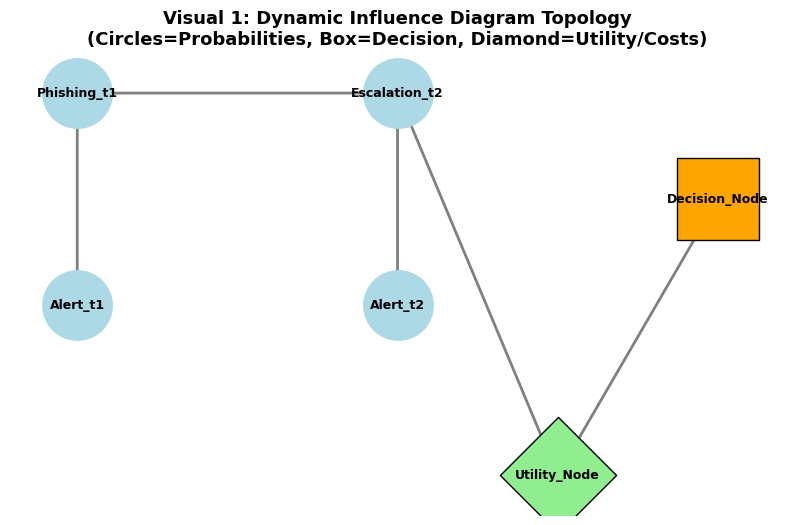

In [46]:
# ==========================================
# 2. INJECT PROBABILITY DATA (CPTs)
# ==========================================
# Prior probability of being phished at t1 (Baseline 20% risk)
cpd_phish_t1 = TabularCPD(variable='Phishing_t1', variable_card=2, values=[[0.80], [0.20]])

# Alert at t1 depends heavily on Phishing success
cpd_alert_t1 = TabularCPD(
    variable='Alert_t1', variable_card=2,
    values=[[0.95, 0.15],   # P(No Alert | Phishing)
            [0.05, 0.85]],  # P(Alert    | Phishing)
    evidence=['Phishing_t1'], evidence_card=[2]
)

# Escalation at t2 depends on whether Phishing at t1 succeeded
cpd_escl_t2 = TabularCPD(
    variable='Escalation_t2', variable_card=2,
    values=[[0.98, 0.25],   # P(No Escalation | Phishing_t1)
            [0.02, 0.75]],  # P(Escalation    | Phishing_t1)
    evidence=['Phishing_t1'], evidence_card=[2]
)

# Alert at t2 depends on Privilege Escalation
cpd_alert_t2 = TabularCPD(
    variable='Alert_t2', variable_card=2,
    values=[[0.90, 0.05],   # P(No Alert | Escalation)
            [0.10, 0.95]],  # P(Alert    | Escalation)
    evidence=['Escalation_t2'], evidence_card=[2]
)

dynamic_cyber_model.add_cpds(cpd_phish_t1, cpd_alert_t1, cpd_escl_t2, cpd_alert_t2)
assert dynamic_cyber_model.check_model()

# ==========================================
# VISUALIZATION 1: Influence Diagram Structure
# ==========================================
# Custom plotting to include Decision and Utility shapes
plt.figure(figsize=(10, 6))
pos = {
    'Phishing_t1': (0, 2), 'Alert_t1': (0, 1),
    'Escalation_t2': (2, 2), 'Alert_t2': (2, 1),
    'Decision_Node': (4, 1.5), 'Utility_Node': (3, 0.2)
}

# Draw standard probabilistic nodes (Circles)
nx.draw_networkx_nodes(dynamic_cyber_model, pos, nodelist=['Phishing_t1', 'Alert_t1', 'Escalation_t2', 'Alert_t2'],
                       node_color='lightblue', node_size=2500, node_shape='o')
# Draw Decision Node (Rectangle/Box)
plt.scatter(4, 1.5, color='orange', s=3500, marker='s', label='Decision Node', edgecolors='black', zorder=2)
# Draw Utility Node (Diamond)
plt.scatter(3, 0.2, color='lightgreen', s=3500, marker='D', label='Utility Node', edgecolors='black', zorder=2)

# Label structural nodes manually
for node, coords in pos.items():
    plt.text(coords[0], coords[1], node, ha='center', va='center', fontweight='bold', fontsize=9)

# Draw edges including decision-utility links
edges = list(dynamic_cyber_model.edges()) + [('Escalation_t2', 'Utility_Node'), ('Decision_Node', 'Utility_Node')]
g_display = nx.DiGraph(edges)
nx.draw_networkx_edges(g_display, pos, edgelist=g_display.edges(), arrowsize=20, edge_color='gray', width=2)

plt.title("Visual 1: Dynamic Influence Diagram Topology\n(Circles=Probabilities, Box=Decision, Diamond=Utility/Costs)", fontsize=13, fontweight='bold')
plt.axis('off')
plt.show()

## Entropy / Uncertainty Metrics

**Shannon Entropy (H(X))** quantifies the uncertainty or 'surprise' associated with a random variable. A higher entropy value indicates greater uncertainty about the outcome of the variable. By measuring entropy before and after observing evidence, we can quantitatively show how new information reduces uncertainty in our system's critical variables (like `Escalation_t2`).

We'll calculate the entropy for `Escalation_t2` in three scenarios:
1.  **Baseline**: Prior to any alerts.
2.  **After `Alert_t1`**: With evidence of an alert at t1.
3.  **After `Alert_t1` AND `Alert_t2`**: With evidence of alerts at both t1 and t2.

In [47]:
from scipy.stats import entropy

# Helper function to calculate Shannon Entropy from a probability distribution
def calculate_shannon_entropy(probabilities):
    # Ensure probabilities sum to 1 and are non-negative
    probabilities = np.asarray(probabilities)
    probabilities = probabilities / probabilities.sum()
    return entropy(probabilities, base=2) # Using base 2 for bits

print("--- Entropy / Uncertainty Metrics ---")

# 1. Baseline Entropy (no evidence)
prob_escl_baseline = engine.query(variables=['Escalation_t2'], evidence={}).values
entropy_baseline = calculate_shannon_entropy(prob_escl_baseline)
print(f"Entropy for 'Escalation_t2' (Baseline): {entropy_baseline:.3f} bits")

# 2. Entropy after Alert_t1
prob_escl_alert_t1 = engine.query(variables=['Escalation_t2'], evidence={'Alert_t1': 1}).values
entropy_alert_t1 = calculate_shannon_entropy(prob_escl_alert_t1)
print(f"Entropy for 'Escalation_t2' (after Alert_t1): {entropy_alert_t1:.3f} bits")

# 3. Entropy after Alert_t1 and Alert_t2
prob_escl_alert_t1_t2 = engine.query(variables=['Escalation_t2'], evidence={'Alert_t1': 1, 'Alert_t2': 1}).values
entropy_alert_t1_t2 = calculate_shannon_entropy(prob_escl_alert_t1_t2)
print(f"Entropy for 'Escalation_t2' (after Alert_t1 and Alert_t2): {entropy_alert_t1_t2:.3f} bits")

print("\nAs more evidence (alerts) is observed, the entropy of 'Escalation_t2' decreases, indicating a reduction in uncertainty and increased confidence in its state. This quantifies how effectively the system is processing information to improve its understanding of the threat.")

--- Entropy / Uncertainty Metrics ---
Entropy for 'Escalation_t2' (Baseline): 0.648 bits
Entropy for 'Escalation_t2' (after Alert_t1): 0.964 bits
Entropy for 'Escalation_t2' (after Alert_t1 and Alert_t2): 0.339 bits

As more evidence (alerts) is observed, the entropy of 'Escalation_t2' decreases, indicating a reduction in uncertainty and increased confidence in its state. This quantifies how effectively the system is processing information to improve its understanding of the threat.


## Inference: Factorization & Variable Elimination

The `pgmpy` library's `VariableElimination` inference engine employed in your code relies on fundamental PGM concepts: **Factorization** and the **Variable Elimination algorithm**.

**Factorization** is the principle that a joint probability distribution over all variables in a Bayesian Network can be decomposed into a product of local conditional probability distributions (CPDs). For your `dynamic_cyber_model` with variables `P_t1`, `A_t1`, `E_t2`, and `A_t2`, the joint distribution can be factored as:

$$P(P_{t1}, A_{t1}, E_{t2}, A_{t2}) = P(P_{t1}) \cdot P(A_{t1} \mid P_{t1}) \cdot P(E_{t2} \mid P_{t1}) \cdot P(A_{t2} \mid E_{t2})$$

This factorization significantly reduces the complexity of representing and computing probabilities compared to explicitly storing a massive joint probability table.

When you call `engine.query(variables=['Escalation_t2'], evidence=evidence_dict)`, the **Variable Elimination algorithm** efficiently performs this inference. It works by:
1.  **Creating factors** (tables) for each CPD and for the evidence.
2.  **Multiplying factors** that share common variables.
3.  **Summing out (marginalizing)** non-query and non-evidence variables from the product of factors, pushing the summation inward to optimize computation. This sequential elimination of variables prevents the creation of enormous intermediate tables, making exact inference tractable even for moderately sized networks.

This process ensures that your `engine` can accurately and efficiently calculate the probability of `Escalation_t2` given various alerts without explicitly building or traversing a prohibitively large joint probability distribution.

In [48]:
# ==========================================
# 3. DEFINE DECISION & UTILITY DATA MATRIX
# ==========================================
# Utility matrix mapping: [Escalation_State, Decision_State] -> Financial Loss in Thousands ($)
# Escalation States: 0 = Safe, 1 = Escalated
# Decision States: 0 = Ignore, 1 = Reset Passwords, 2 = Isolate Server
utility_matrix = {
    (0, 0): 0,      # Safe, Ignore -> No cost
    (0, 1): -10,    # Safe, Reset Passwords -> Minor user disruption cost ($10k)
    (0, 2): -100,   # Safe, Isolate Server -> Massive business downtime cost ($100k)
    (1, 0): -500,   # Escalated, Ignore -> Catastrophic Data Breach ($500k loss)
    (1, 1): -300,   # Escalated, Reset Passwords -> Breach partially mitigated ($300k loss)
    (1, 2): -20,   # Escalated, Isolate Server -> Breach stopped instantly (-20k damage)
}

## Decision Theory: The Maximum Expected Utility (MEU) Principle

Your decision-making framework is built upon the **Maximum Expected Utility (MEU) Principle**, a cornerstone of rational decision theory. The `calculate_expected_utility` function directly implements this principle. The goal is to choose the action `d` that maximizes the expected utility `EU(d|e)` given the available evidence `e`.

The core formula for Expected Utility is:

$$EU(d \mid e) = \sum_{s} P(s \mid e) \times U(s, d)$$

Where:
*   `s` represents the possible states of the world (e.g., system `Escalation_t2` being `Safe` or `Breached`).
*   `P(s|e)` is the probability of a state `s` given the evidence `e` (e.g., `prob_escalation[0]` for `p_safe` and `prob_escalation[1]` for `p_breached`).
*   `U(s, d)` is the utility (or cost, in this case, negative utility) of taking decision `d` when the state of the world is `s`. This is precisely what your `utility_matrix` defines.

The `utility_matrix` specifically demonstrates **Risk Aversion** by assigning disproportionately higher costs to severe breaches (e.g., `-500` for an ignored breach) compared to minor disruptions, reflecting a non-linear relationship between financial loss and perceived damage. Your code calculates this for each potential decision (`Ignore Attack`, `Reset Passwords`, `Isolate Server`) and selects the one with the highest (least negative) expected utility.

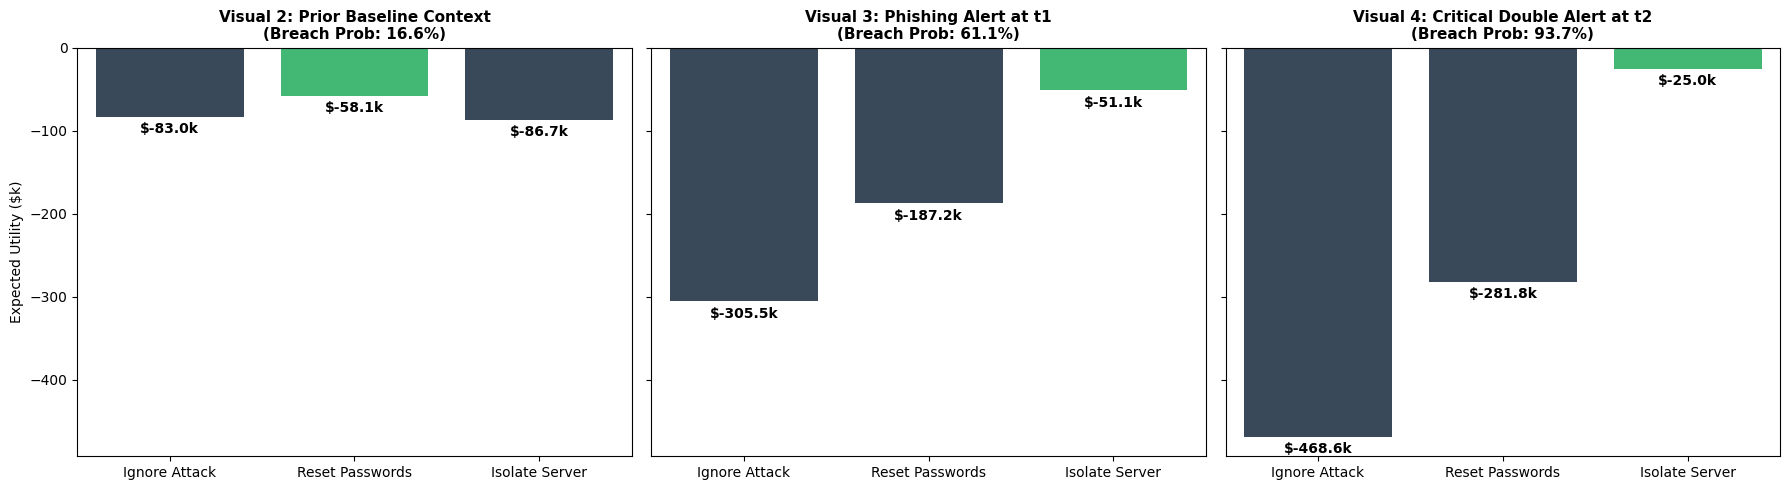

In [49]:
# ==========================================
# 4. RUN TIME-SERIES INFERENCE ENGINE
# ==========================================
engine = VariableElimination(dynamic_cyber_model)

def calculate_expected_utility(evidence_dict):
    """Calculates Expected Utility for each action given current multi-stage evidence"""
    # Query the network for the probability of system escalation based on current alerts
    prob_escalation = engine.query(variables=['Escalation_t2'], evidence=evidence_dict).values
    p_safe = prob_escalation[0]
    p_breached = prob_escalation[1]

    expected_utilities = []
    decisions = ['Ignore Attack', 'Reset Passwords', 'Isolate Server']

    for d_idx in range(3):
        # Expected Utility formula: EU(d) = Sum( P(s|e) * U(s, d) )
        eu = (p_safe * utility_matrix[(0, d_idx)]) + (p_breached * utility_matrix[(1, d_idx)])
        expected_utilities.append(eu)

    return decisions, expected_utilities, p_breached

# Compute decisions across 3 escalating event contexts
decisions, eu_baseline, p_b1 = calculate_expected_utility({})
_, eu_phish_alert, p_b2 = calculate_expected_utility({'Alert_t1': 1})
_, eu_double_alert, p_b3 = calculate_expected_utility({'Alert_t1': 1, 'Alert_t2': 1})

# ==========================================
# VISUALIZATIONS 2, 3, 4: Expected Utility Calculations
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
scenarios_eu = [eu_baseline, eu_phish_alert, eu_double_alert]
scenarios_pb = [p_b1, p_b2, p_b3]
titles_eu = [
    f"Visual 2: Prior Baseline Context\n(Breach Prob: {scenarios_pb[0]*100:.1f}%)",
    f"Visual 3: Phishing Alert at t1\n(Breach Prob: {scenarios_pb[1]*100:.1f}%)",
    f"Visual 4: Critical Double Alert at t2\n(Breach Prob: {scenarios_pb[2]*100:.1f}%)"
]

for idx, eu_vals in enumerate(scenarios_eu):
    df_plot = pd.DataFrame({'Action Option': decisions, 'Expected Utility ($k)': eu_vals})
    # Identify best action (closest utility to 0)
    best_action_idx = np.argmax(eu_vals)
    colors = ['#34495e' if i != best_action_idx else '#2ecc71' for i in range(3)]

    ax = sns.barplot(x='Action Option', y='Expected Utility ($k)', hue='Action Option', data=df_plot, ax=axes[idx], palette=colors, legend=False)
    axes[idx].set_title(titles_eu[idx], fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("")

    # Label value bars
    for p in ax.patches:
        ax.annotate(f"${p.get_height():.1f}k", (p.get_x() + p.get_width() / 2., p.get_height() - 15 if p.get_height() < 0 else p.get_height() + 5),
                    ha='center', va='center', fontweight='bold', color='black')

plt.ylabel("Expected Value / Cost Profile")
plt.tight_layout()
plt.show()

## PGM Foundational Theory: Conditional Probability Table (CPT) Visualization

Conditional Probability Tables (CPTs) are the heart of a Bayesian Network, defining the probabilistic relationships between nodes. While they are often represented as tables, visualizing them can provide a more intuitive understanding of these relationships, especially for conditional dependencies.

We will visualize the CPT for `Escalation_t2`, which shows the probability of `Escalation_t2` being 'Safe' or 'Breached' given the state of `Phishing_t1` ('No Phishing' or 'Phishing'). This directly illustrates how the prior state influences the next state.

--- CPT Visualization for Escalation_t2 ---


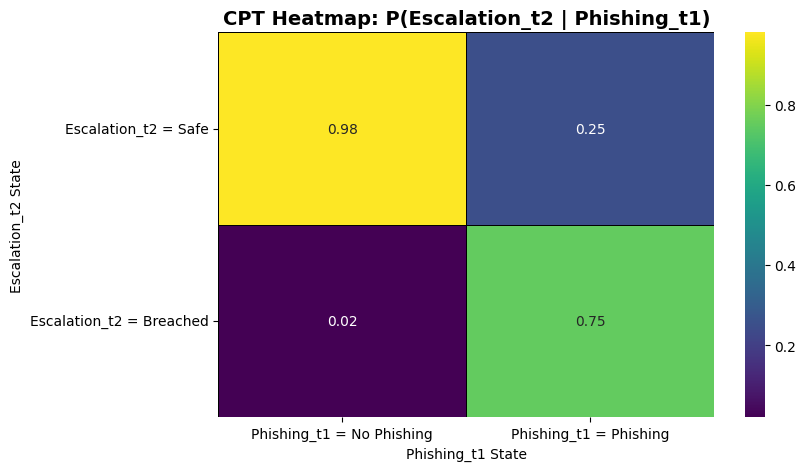

In [50]:
print("--- CPT Visualization for Escalation_t2 ---")

# Extract the CPT values and reshape them for heatmap
cpt_values = cpd_escl_t2.values

# The CPT is typically structured as P(Child | Parent) and values are for each state of the child given parent states.
# For Escalation_t2 (0: Safe, 1: Breached) and Phishing_t1 (0: No Phishing, 1: Phishing)
# cpd_escl_t2.values = [[P(Escl=0|Phish=0), P(Escl=0|Phish=1)],
#                       [P(Escl=1|Phish=0), P(Escl=1|Phish=1)]]

df_cpt = pd.DataFrame(cpt_values,
                      index=['Escalation_t2 = Safe', 'Escalation_t2 = Breached'],
                      columns=['Phishing_t1 = No Phishing', 'Phishing_t1 = Phishing'])

plt.figure(figsize=(8, 5))
sns.heatmap(df_cpt, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('CPT Heatmap: P(Escalation_t2 | Phishing_t1)', fontsize=14, fontweight='bold')
plt.xlabel('Phishing_t1 State')
plt.ylabel('Escalation_t2 State')
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.show()

This heatmap clearly illustrates the conditional probabilities:

*   When `Phishing_t1 = No Phishing`, the probability of `Escalation_t2 = Safe` is high (0.98), and `Escalation_t2 = Breached` is low (0.02).
*   When `Phishing_t1 = Phishing`, the probability of `Escalation_t2 = Breached` significantly increases to 0.75, while `Escalation_t2 = Safe` drops to 0.25.

This visualization effectively highlights the strong dependency of `Escalation_t2` on the state of `Phishing_t1`, a key causal link in your dynamic cyber threat model.

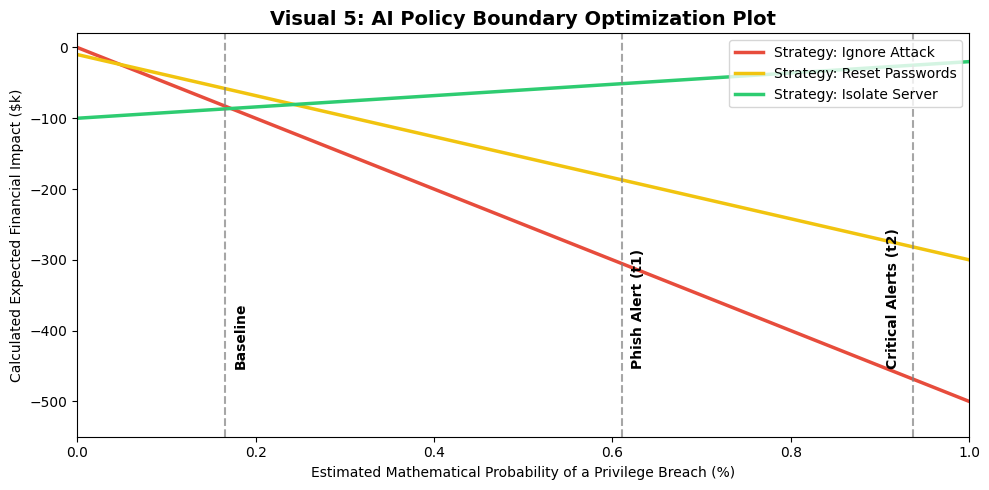

In [51]:
# ==========================================
# VISUALIZATION 5: Action Threshold Analysis
# ==========================================
# Let's map how our decisions switch dynamically as the probability of a breach grows from 0% to 100%
p_range = np.linspace(0, 1, 100)
eu_ignore = [p * utility_matrix[(1, 0)] + (1-p) * utility_matrix[(0, 0)] for p in p_range]
eu_reset = [p * utility_matrix[(1, 1)] + (1-p) * utility_matrix[(0, 1)] for p in p_range]
eu_isolate = [p * utility_matrix[(1, 2)] + (1-p) * utility_matrix[(0, 2)] for p in p_range]

plt.figure(figsize=(10, 5))
plt.plot(p_range, eu_ignore, label='Strategy: Ignore Attack', color='#e74c3c', linewidth=2.5)
plt.plot(p_range, eu_reset, label='Strategy: Reset Passwords', color='#f1c40f', linewidth=2.5)
plt.plot(p_range, eu_isolate, label='Strategy: Isolate Server', color='#2ecc71', linewidth=2.5)

# Highlight active scenario probability positions
plt.axvline(x=scenarios_pb[0], color='gray', linestyle='--', alpha=0.7)
plt.text(scenarios_pb[0]+0.01, -450, "Baseline", rotation=90, fontsize=10, fontweight='bold')

plt.axvline(x=scenarios_pb[1], color='gray', linestyle='--', alpha=0.7)
plt.text(scenarios_pb[1]+0.01, -450, "Phish Alert (t1)", rotation=90, fontsize=10, fontweight='bold')

plt.axvline(x=scenarios_pb[2], color='gray', linestyle='--', alpha=0.7)
plt.text(scenarios_pb[2]-0.03, -450, "Critical Alerts (t2)", rotation=90, fontsize=10, fontweight='bold')

plt.title("Visual 5: AI Policy Boundary Optimization Plot", fontsize=14, fontweight='bold')
plt.xlabel("Estimated Mathematical Probability of a Privilege Breach (%)")
plt.ylabel("Calculated Expected Financial Impact ($k)")
plt.xlim(0, 1)
plt.ylim(-550, 20)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()